# A1 -- Corpus Exploration: Bangla Handwritten Dolil Dataset

Domain: **Land Registry Archives & Legal Aid**. Data speciality: **Bangla-English code-switching &
handwriting**. This notebook explores the raw scanned corpus in `data/raw/` and backs the claims in
`data/provenance.md` and the A1 form with real, re-runnable numbers (not just estimates).

Run from the repo root (`jupyter notebook` / `jupyter lab` launched at `doc-agent-12/`). Takes
roughly 20-25 minutes end-to-end (653 pages x 4 rotations for the rotation-invariant duplicate check in Section 3 is the slow part).

In [1]:
import glob
import os
import time
from pathlib import Path

from PIL import Image
import numpy as np
import imagehash

# Resolve the repo root regardless of where Jupyter was launched from.
ROOT = Path.cwd()
while not (ROOT / "data" / "raw").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
RAW_DIR = ROOT / "data" / "raw"
assert RAW_DIR.exists(), f"data/raw not found -- run scripts/get_data.sh first. Looked under {ROOT}"
RAW_DIR

WindowsPath('D:/cse/4-1/429/doc-agent-12/data/raw')

## 1. Inventory -- how many pages do we actually have?

The dataset ships 653 JPEGs. An earlier pass of this notebook flagged the 44 smallest files
(<200KB) as "thumbnail/corrupt" and dropped them from the usable count. **That was wrong** --
spot-checking those files directly (23 of the 44, spread across both size and file-id ranges)
showed every single one is a real, legible scanned deed page, just more compressed or
lower-resolution than the rest of the batch. File size alone doesn't distinguish a smaller-but-
real scan from an actually blank/corrupt one.

So instead we check what file size *can't* tell us: whether each file is actually a valid,
openable image of a reasonable size. That's a real integrity check, not a proxy.

In [2]:
files = sorted(RAW_DIR.glob("*.jpg"))
print("total files:", len(files))

MIN_DIM = 200  # px -- a genuine scanned page is nowhere near this small; catches true corruption


def is_valid_page(path):
    try:
        with Image.open(path) as im:
            im.verify()
        with Image.open(path) as im:  # verify() invalidates the handle -- reopen to read size
            w, h = im.size
        return w >= MIN_DIM and h >= MIN_DIM
    except Exception:
        return False


bad_files = [f for f in files if not is_valid_page(f)]
usable_files = [f for f in files if f not in set(bad_files)]

print("failed integrity check (unopenable / too small):", len(bad_files))
print("usable pages:", len(usable_files))
if bad_files:
    print("bad file ids:", [f.stem for f in bad_files])

total files: 653


failed integrity check (unopenable / too small): 0
usable pages: 653


**Result:** all 653 raw files pass the integrity check -- **653 usable pages**. No pages are
dropped as thumbnail/corrupt; the file-size threshold in an earlier version of this notebook was
not a real signal (confirmed by direct visual inspection, see above) and has been removed.

Meets the corpus floor: **653 >= 300 usable pages.** Word count can't be computed yet -- this corpus
is handwritten with no separate text layer, so word count only becomes available once the Stage 3
VLM/HTR reader runs in A2 (A1 estimate: ~95,000 words, now over 653 pages rather than 609).

In [3]:
total_bytes = sum(f.stat().st_size for f in files)
print(f"total size on disk: {total_bytes/1e9:.2f} GB")

sizes_kb = np.array([f.stat().st_size for f in usable_files]) / 1024
print(f"usable-page size (KB): min={sizes_kb.min():.0f} p50={np.median(sizes_kb):.0f} "
      f"max={sizes_kb.max():.0f}")

total size on disk: 2.33 GB
usable-page size (KB): min=43 p50=3968 max=5920


## 2. Scan quality -- a legibility proxy

We don't have OCR yet, so we approximate "how hard will this page be to read" with a sharpness
proxy: downscale to a max dimension of 800px (keeps this fast and removes JPEG-block noise at
full-res), take a discrete Laplacian, and use its variance -- low variance means a flat, faded,
low-contrast page; high variance means crisp ink edges and heavy background texture/seals.

We sanity-checked this against two pages by eye:
- `dolil_186` (variance ~ 460) -- genuinely faded ballpoint on a worn, rotated scan, hard to read.
- `dolil_1` (variance ~ 10,300) -- crisp printed stamp-paper border, dark ink, high contrast.

That confirms the metric points the right direction, so we use it as a relative ranking rather
than a calibrated absolute score.

In [4]:
def legibility_raw(path, max_dim=800):
    im = Image.open(path).convert("L")
    w, h = im.size
    scale = max_dim / max(w, h)
    if scale < 1:
        im = im.resize((max(1, int(w * scale)), max(1, int(h * scale))))
    arr = np.asarray(im, dtype=np.float32)
    lap = (
        4 * arr[1:-1, 1:-1]
        - arr[:-2, 1:-1]
        - arr[2:, 1:-1]
        - arr[1:-1, :-2]
        - arr[1:-1, 2:]
    )
    return float(lap.var())


t0 = time.time()
records = []
for f in usable_files:
    im = Image.open(f)
    w, h = im.size
    records.append({
        "page_id": f.stem,
        "path": str(f),
        "width": w,
        "height": h,
        "size_bytes": f.stat().st_size,
        "lap_var": legibility_raw(f),
    })
print(f"processed {len(records)} pages in {time.time() - t0:.1f}s")

processed 653 pages in 63.6s


In [5]:
lap_vars = np.array([r["lap_var"] for r in records])
for p in (0, 10, 25, 50, 75, 90, 100):
    print(f"p{p:>3}: {np.percentile(lap_vars, p):9.1f}")

LOW_LEGIBILITY_THRESHOLD = 900.0  # picked from the eyeballed dolil_186 vs dolil_1 comparison above
low_band = [r for r in records if r["lap_var"] < LOW_LEGIBILITY_THRESHOLD]
print()
print(f"low-legibility band (lap_var < {LOW_LEGIBILITY_THRESHOLD:.0f}): "
      f"{len(low_band)}/{len(records)} = {len(low_band)/len(records)*100:.1f}%")

p  0:      19.1
p 10:     225.2
p 25:     915.7
p 50:    1745.4
p 75:    2866.0
p 90:    4725.4
p100:   19184.8

low-legibility band (lap_var < 900): 159/653 = 24.3%


**Finding:** 159/653 = 24.3% of usable pages fall in the low-legibility band by this proxy --
close to, though a bit lower than, the ~30% the team eyeballed for the A1 form. That's an expected
gap between "worst-look manual skim" and a cheap automated proxy (this metric only sees
*contrast/sharpness*, not e.g. seal overlap or show-through, which a human spots faster than a
Laplacian does). We keep the manual estimate in the form as a qualitative flag and treat this
notebook's number as the reproducible baseline -- worth re-checking once the VLM reader gives a
real per-page confidence score in A2. (This is measured over all 653 pages, now that the earlier
44-page exclusion in Section 1 has been corrected -- see above.)

**What this means for the build:** a meaningful low-legibility band either way confirms
enhancement (Stage 1) isn't optional for this corpus -- it's gated in for our profile.

## 3. Near-duplicate check (the leakage AND indexing guard)

We perceptual-hash (pHash) every usable page and flag pairs closer than a small Hamming-distance
threshold. **Rotation-invariant**: a first version of this check hashed pages as-is and missed
121 real matches where one copy was rotated relative to the other (pHash is not rotation-invariant
-- a page and its 90-degree-rotated duplicate hash nowhere near each other). This version hashes
each page at 0/90/180/270 degrees and takes the minimum distance across all 16 rotation
combinations of a pair, so a duplicate is caught regardless of which way either copy was scanned.

Two things to look for:
1. **Expected**: pairs among *consecutive* page numbers -- these are almost certainly sheets of the
   same multi-sheet deed (shared stamp-paper design, similar layout), which is exactly the signal
   A2 will use to seed deed grouping.
2. **Unexpected**: pairs between *far-apart* page numbers -- these need a human look, since they
   could be an accidental re-scan or duplicate rather than a real deed relationship.

**This isn't only a split-leakage check.** If the same physical page was photographed twice, both
copies get OCR'd and indexed, retrieval returns the same content twice, and the chunk count
overstates how much corpus this actually is. A dedup step before indexing (Stage 4) needs this
pair list too, not just the split logic below.

In [6]:
t0 = time.time()


def hashes_all_rotations(path, n=4):
    hs = []
    with Image.open(path) as im:
        cur = im.copy()
        for _ in range(n):
            hs.append(imagehash.phash(cur))
            cur = cur.rotate(90, expand=True)
    return hs


rot_hashes = {r["page_id"]: hashes_all_rotations(r["path"]) for r in records}
print(f"hashed {len(rot_hashes)} pages x 4 rotations in {time.time() - t0:.1f}s")

items = list(rot_hashes.items())
DIST_THRESHOLD = 6
near_dup_pairs = []
t1 = time.time()
for i in range(len(items)):
    hi = items[i][1]
    for j in range(i + 1, len(items)):
        hj = items[j][1]
        d = min(a - b for a in hi for b in hj)
        if d <= DIST_THRESHOLD:
            near_dup_pairs.append((items[i][0], items[j][0], int(d)))
print(f"pairwise compare in {time.time() - t1:.1f}s")

print(f"rotation-invariant near-duplicate pairs (Hamming <= {DIST_THRESHOLD}): {len(near_dup_pairs)}")

hashed 653 pages x 4 rotations in 226.9s


pairwise compare in 7.5s
rotation-invariant near-duplicate pairs (Hamming <= 6): 211


In [7]:
def page_num(page_id):
    return int(page_id.split("_")[1])


consecutive = [p for p in near_dup_pairs if abs(page_num(p[0]) - page_num(p[1])) <= 2]
distant = [p for p in near_dup_pairs if abs(page_num(p[0]) - page_num(p[1])) > 2]

print(f"consecutive-number pairs (expected, likely same-deed sheets): {len(consecutive)}")
print(f"far-apart pairs (needs a human look): {len(distant)}")
print()
print("far-apart pairs:")
for a, b, d in distant:
    print(f"  {a} <-> {b}  (distance={d})")

consecutive-number pairs (expected, likely same-deed sheets): 48
far-apart pairs (needs a human look): 163

far-apart pairs:
  dolil_102 <-> dolil_37  (distance=6)
  dolil_190 <-> dolil_225  (distance=6)
  dolil_224 <-> dolil_494  (distance=6)
  dolil_325 <-> dolil_343  (distance=6)
  dolil_326 <-> dolil_335  (distance=2)
  dolil_326 <-> dolil_336  (distance=6)
  dolil_326 <-> dolil_339  (distance=4)
  dolil_326 <-> dolil_341  (distance=6)
  dolil_326 <-> dolil_344  (distance=6)
  dolil_326 <-> dolil_345  (distance=6)
  dolil_326 <-> dolil_347  (distance=4)
  dolil_326 <-> dolil_348  (distance=6)
  dolil_326 <-> dolil_364  (distance=6)
  dolil_326 <-> dolil_398  (distance=6)
  dolil_334 <-> dolil_372  (distance=6)
  dolil_334 <-> dolil_376  (distance=6)
  dolil_334 <-> dolil_387  (distance=4)
  dolil_334 <-> dolil_409  (distance=4)
  dolil_335 <-> dolil_339  (distance=2)
  dolil_335 <-> dolil_344  (distance=4)
  dolil_335 <-> dolil_348  (distance=6)
  dolil_335 <-> dolil_398  (distance

**Finding:** 211 rotation-invariant pairs total -- 48 consecutive-page, 163 far-apart. **121 of
the 211 were invisible to the orientation-naive version of this check** (it only found 90):
any duplicate where one copy was rotated relative to the other hashed nowhere near its match
until rotation was accounted for. That's not a small correction -- most of what this check finds
was hidden by orientation alone.

Looking at the far-apart ids, some line up with the corpus using a handful of repeated
stamp-paper denominations (Tk 45, Tk 500, etc.) whose printed border/seal design is near-identical
across many unrelated deeds -- pHash picking up shared background, not necessarily real duplicate
content. Others (see Section 6 below) look like genuine same-deed sheets scattered across the file
order, or genuine re-scans. So this signal is still not a clean stand-in for deed grouping on its
own; every far-apart pair is worth a human check before being trusted -- both for the split
leakage question and for whether it should be deduplicated before indexing.

## 4. Three example pages

Matches Section 3 of the A1 form. Ids and notes below; thumbnails rendered from `data/raw/`.

dolil_13: Purple-ink deed on Tk 2 stamp paper; part of a multi-sheet deed (serials 2162843-45 run across dolil_13-15). Moderate legibility.


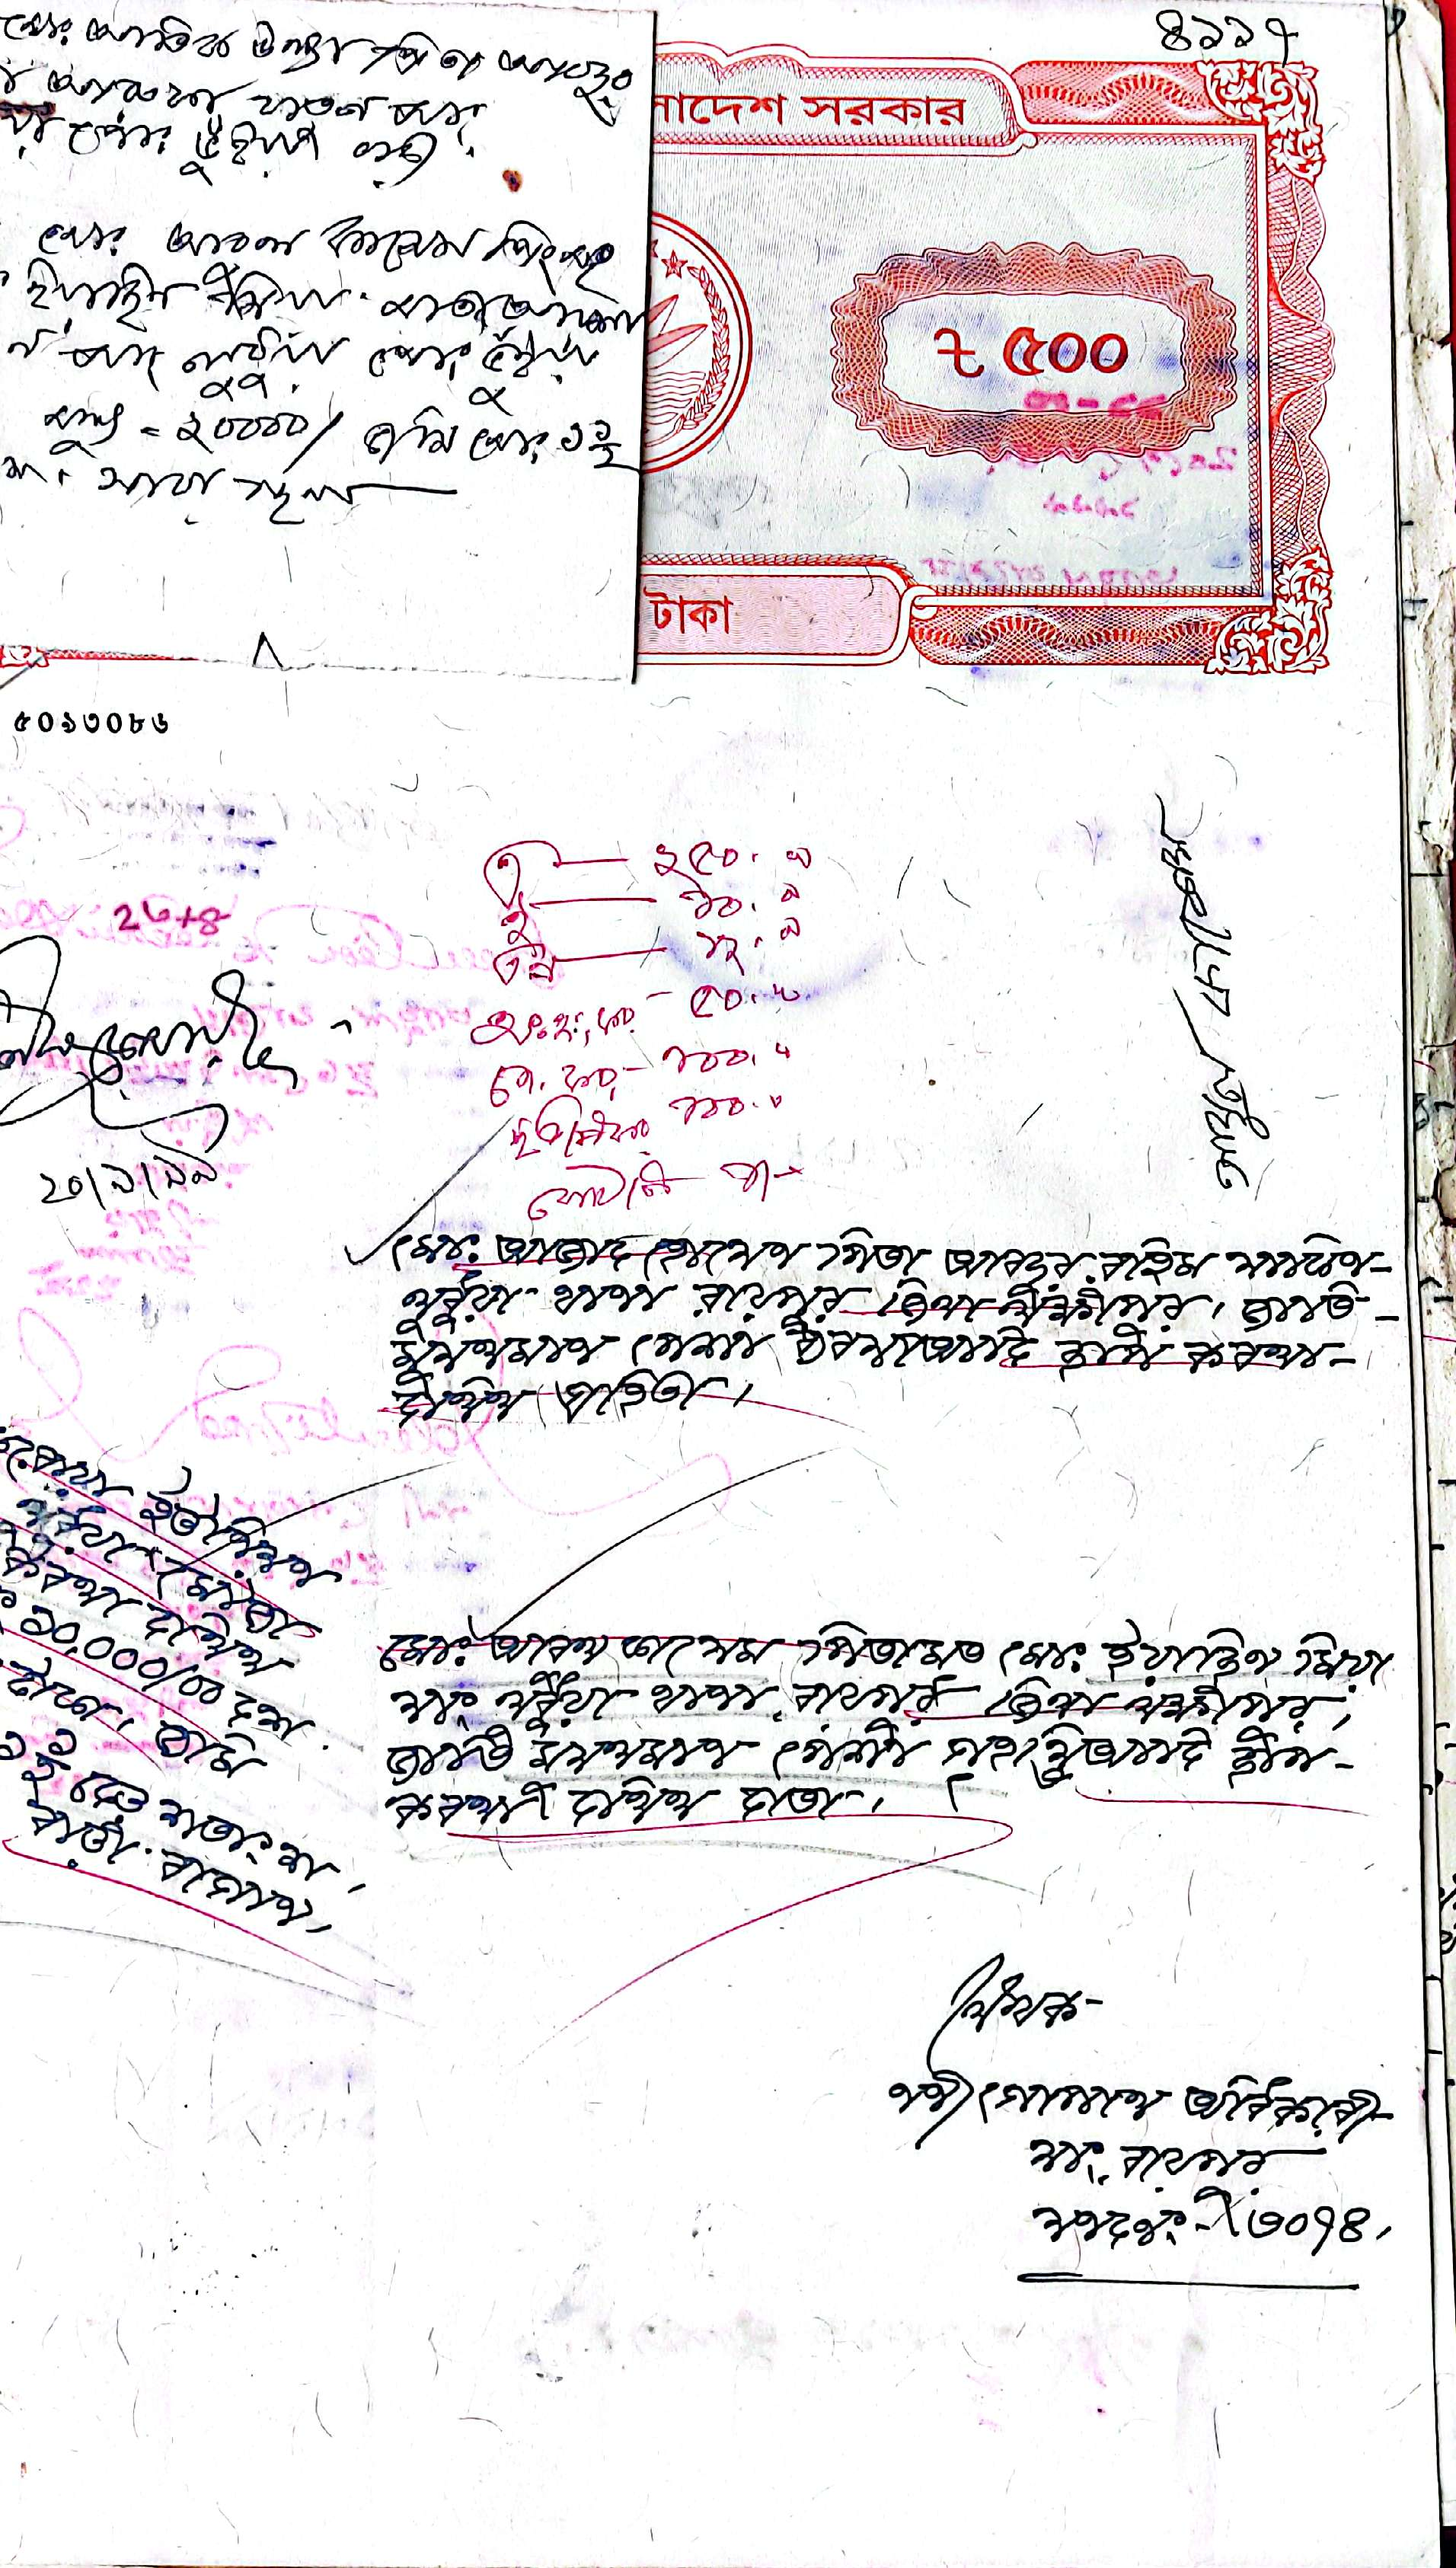

dolil_20: Oldest band - British-era 'ONE RUPEE EIGHT ANNAS' stamp, printed in English + Bangla. Degraded, high-contrast scan.


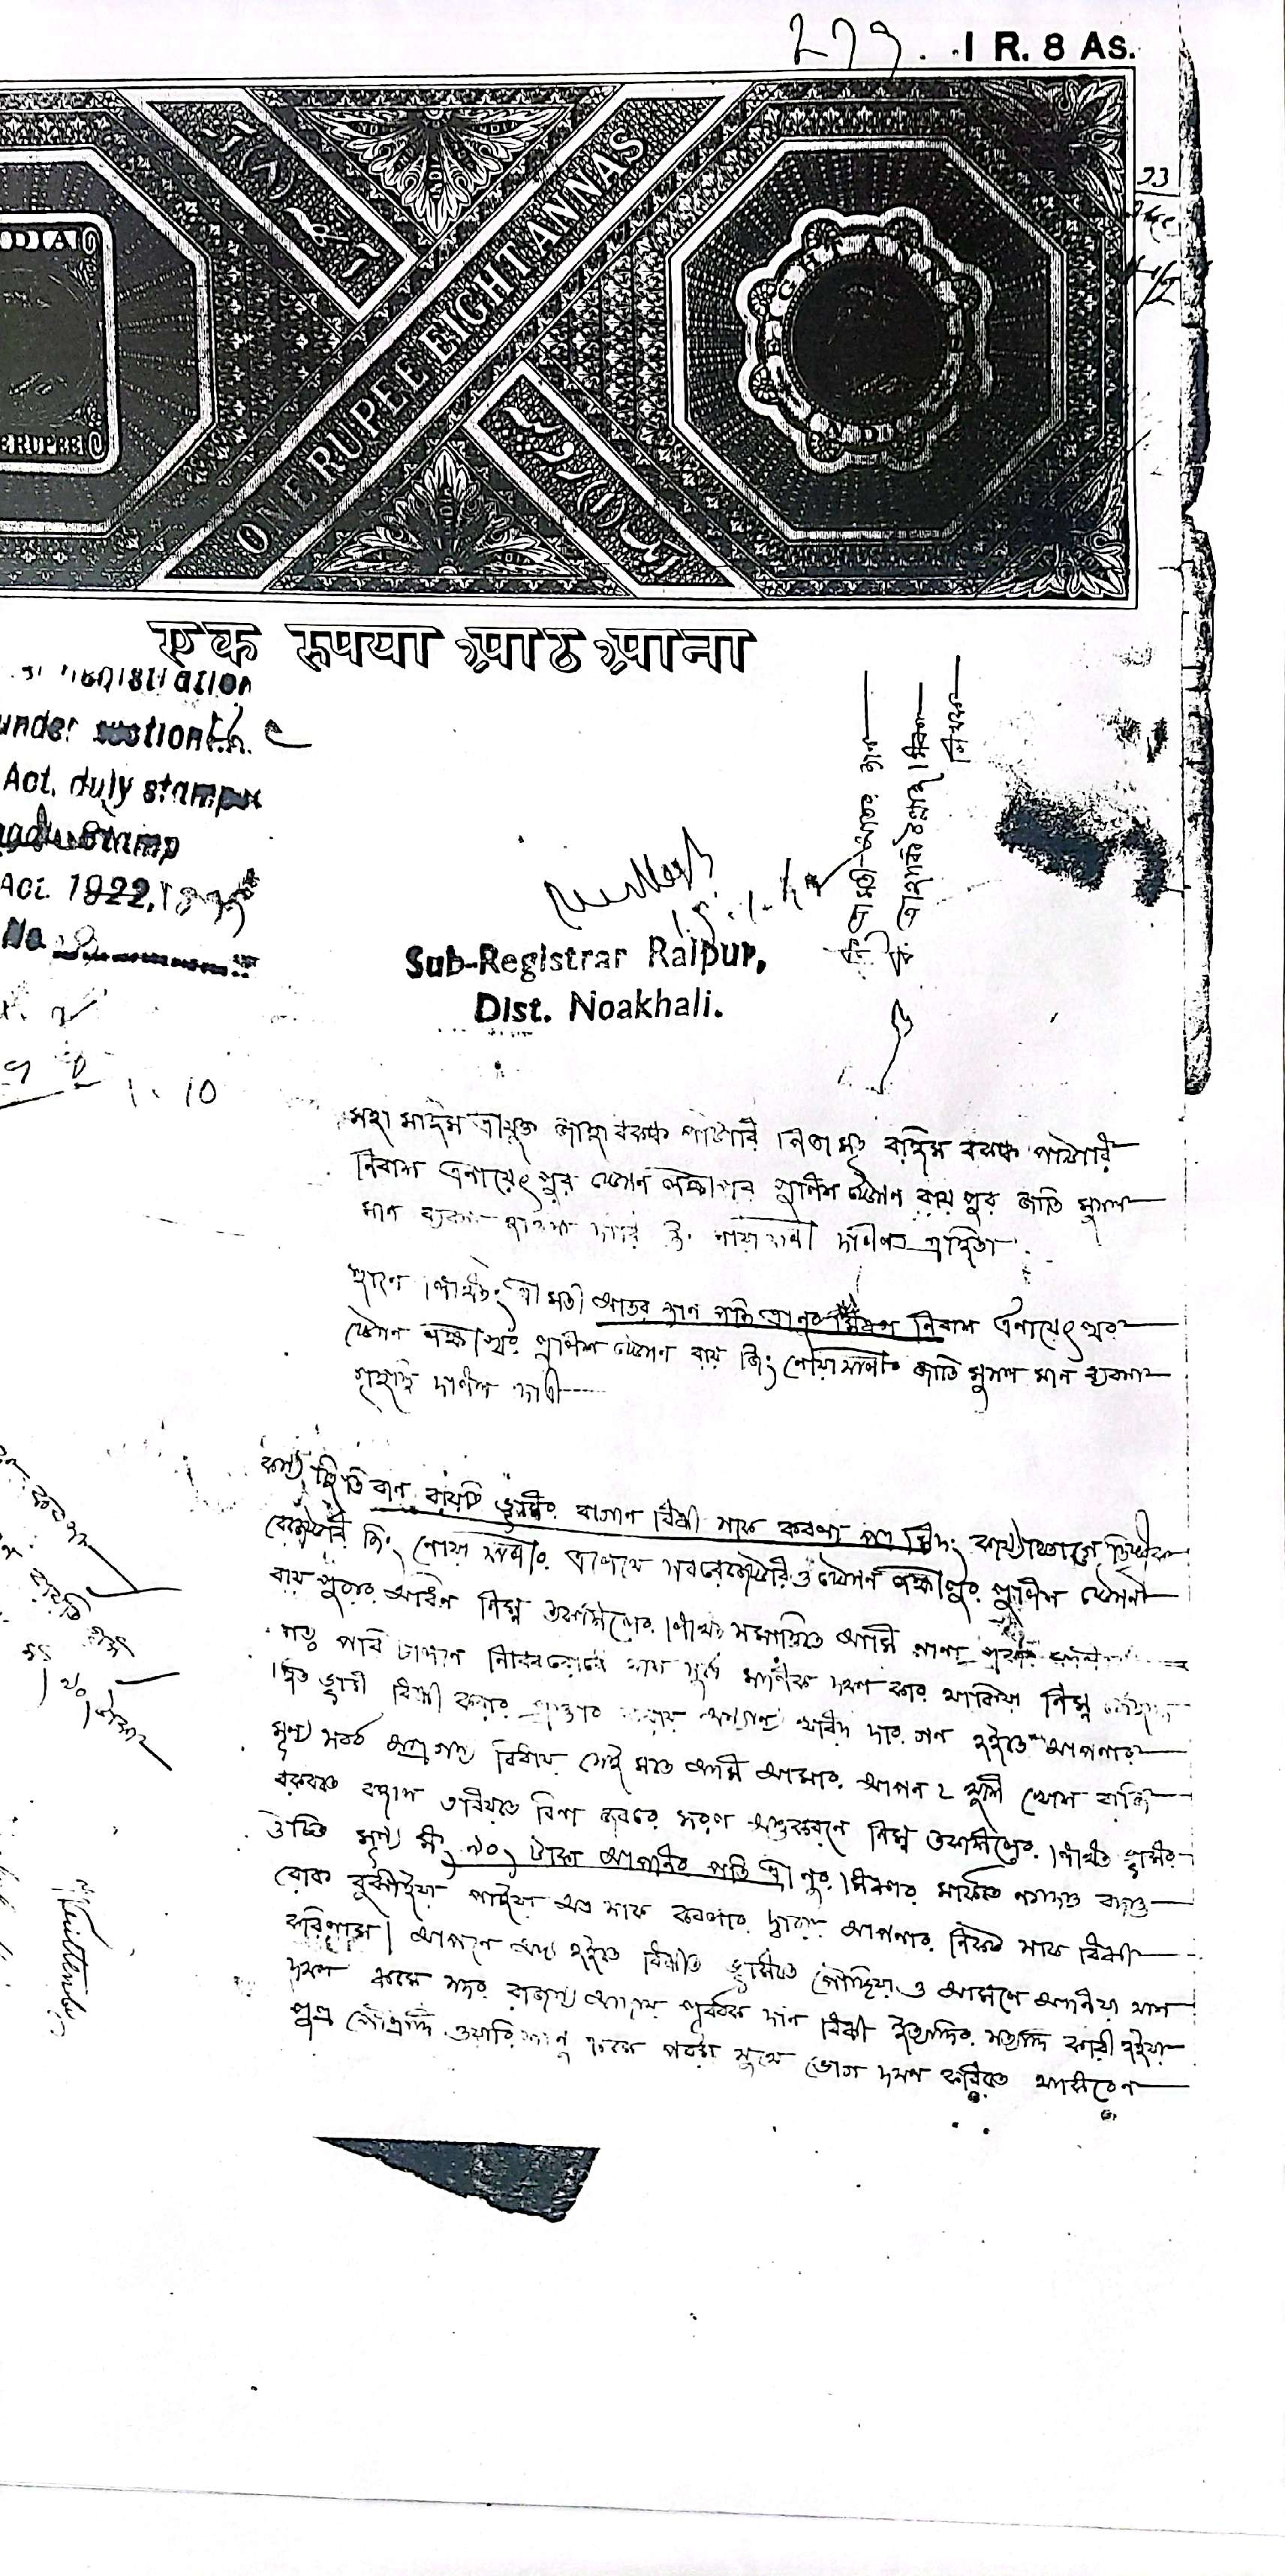

dolil_11: Red-ink deed on Tk 45 stamp paper; heavy marginal annotations and a round registry seal. Serial 0852784.


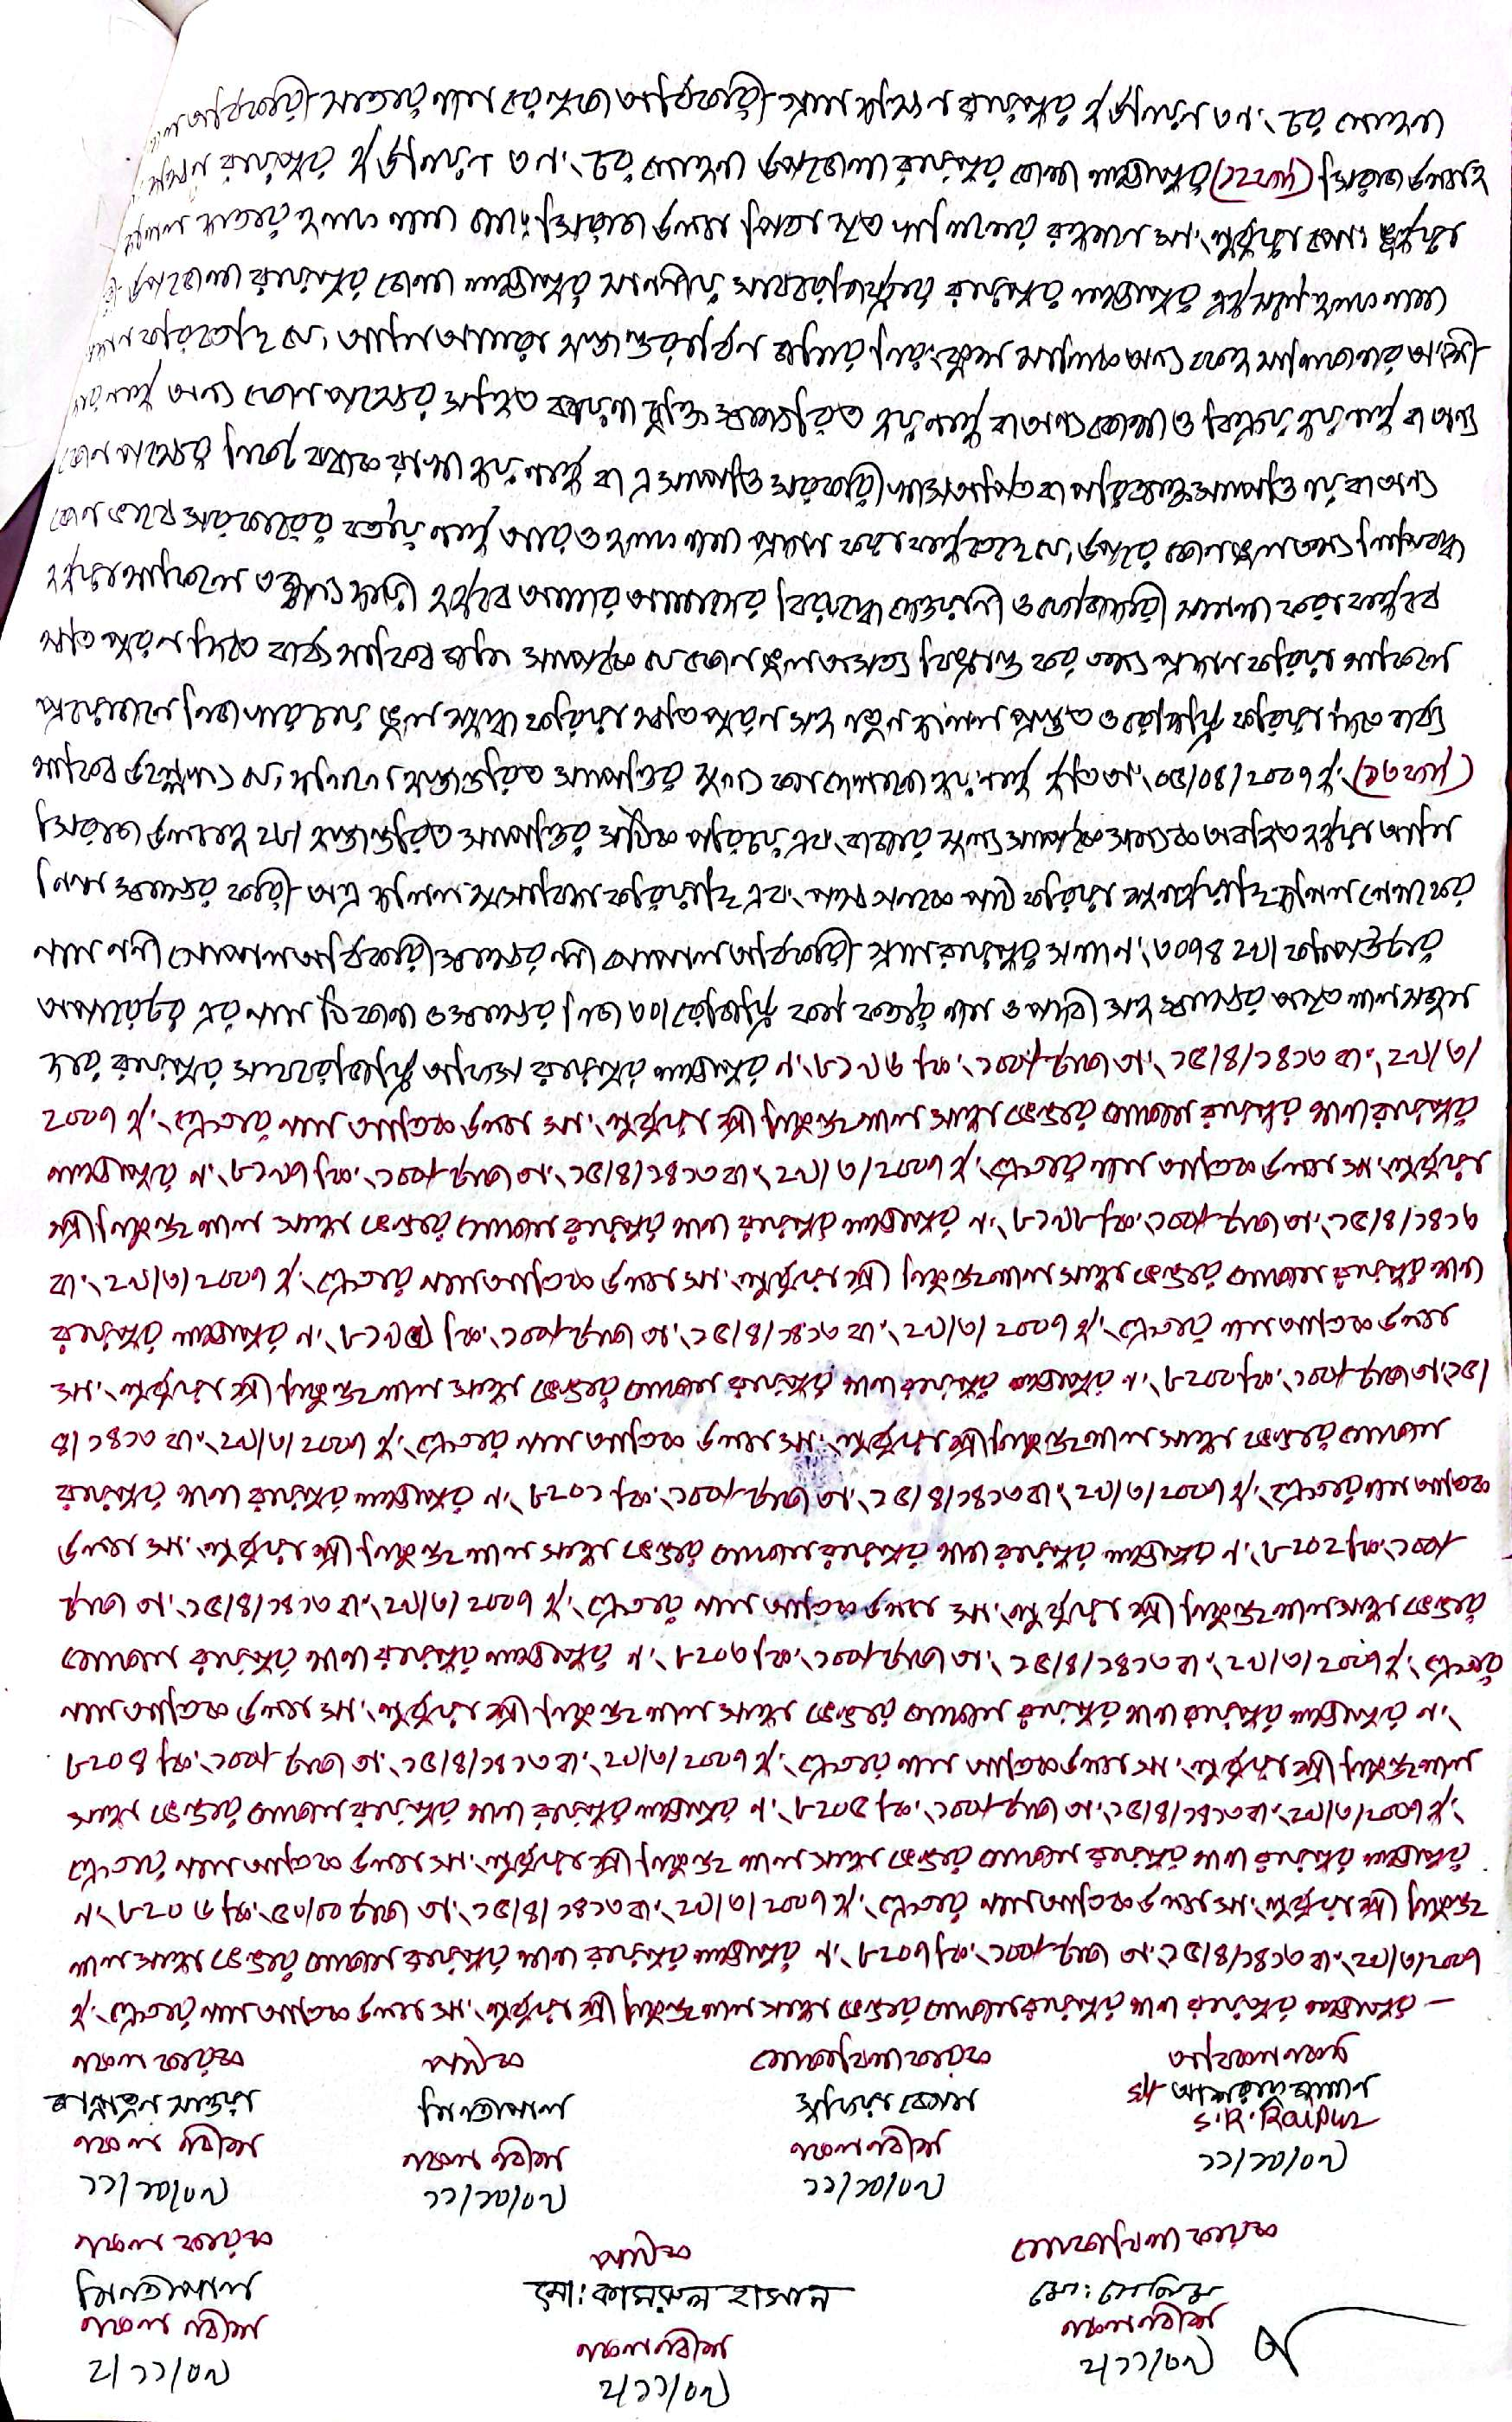

In [8]:
from IPython.display import Image as IPyImage, display

examples = [
    ("dolil_13", "Purple-ink deed on Tk 2 stamp paper; part of a multi-sheet deed "
                  "(serials 2162843-45 run across dolil_13-15). Moderate legibility."),
    ("dolil_20", "Oldest band - British-era 'ONE RUPEE EIGHT ANNAS' stamp, printed in "
                  "English + Bangla. Degraded, high-contrast scan."),
    ("dolil_11", "Red-ink deed on Tk 45 stamp paper; heavy marginal annotations and a "
                  "round registry seal. Serial 0852784."),
]
for page_id, note in examples:
    path = RAW_DIR / f"{page_id}.jpg"
    print(f"{page_id}: {note}")
    display(IPyImage(filename=str(path), width=350))

## 5. Train/val/test split (page-order, buffered)

The first version of this section tried a deed-group placeholder (a handful of hand-labelled
groups from Section 3, plus one singleton group per remaining page) and split by hashing those
groups. That placeholder didn't reflect real deed structure, and the leak check caught it: 52 of
the 90 near-duplicate pairs from Section 3 landed in different splits. (That 52 was measured
back when Section 1 still wrongly excluded 44 pages -- the corpus is 653 pages, not 609; the
numbers below are the corrected, current run.)

Until A2's VLM/HTR reader gives us real registry serials to group multi-sheet deeds properly, we
switch to a simpler, safer stand-in: sort pages by page number (`dolil_1, dolil_2, ...`, which
tracks scan/deed order closely per Section 2 of the A1 form) and cut 70/15/15 in that order. A
deed that straddles a cut point is the actual risk, so we additionally drop `GAP` pages
immediately before *each* cut into a `skipped` list, excluded from every split.

**`GAP = 20`, not 6.** A manual pass over the first 185 pages (grouping pages into deeds by eye)
found deed lengths up to **17 sheets** (`dolil_114-123,125-131`, 17 pages; `dolil_151-156,158-164`,
13 pages; `dolil_39-48,50`, 11 pages). A 6-page buffer cannot protect a 17-page deed from straddling
a cut. 20 gives headroom above the longest deed observed so far, at the cost of ~40 pages (out of
653) dropped from measurement -- cheap, and now a measured choice instead of a guess: *"buffer set
to 20 because the longest deed observed in a manual pass of 185 pages was 17 sheets."* This is
still a placeholder (a deed could in principle run longer than 20 sheets across a cut, and it does
nothing for near-duplicates that are far apart in page order -- see below), but it's a real,
checkable improvement, and A2 replaces it outright once serials are read for all pages.

In [9]:
def page_num(page_id):
    return int(page_id.split("_")[1])


usable_ids = sorted((r["page_id"] for r in records), key=page_num)
n = len(usable_ids)

CUT1 = round(0.70 * n)   # train/val boundary
CUT2 = round(0.85 * n)   # val/test boundary (70% + 15%)
GAP = 20                 # pages dropped just before each cut -- see justification above
                         # (longest deed observed in a manual 185-page pass was 17 sheets)

train_ids = usable_ids[:CUT1 - GAP]
skipped_1 = usable_ids[CUT1 - GAP:CUT1]
val_ids = usable_ids[CUT1:CUT2 - GAP]
skipped_2 = usable_ids[CUT2 - GAP:CUT2]
test_ids = usable_ids[CUT2:]
skipped_ids = skipped_1 + skipped_2

split_assignment = {}
for pid in train_ids:
    split_assignment[pid] = "train"
for pid in val_ids:
    split_assignment[pid] = "val"
for pid in test_ids:
    split_assignment[pid] = "test"
# skipped_ids intentionally get no entry in split_assignment -- excluded from all three splits

print(f"train:   {len(train_ids)}")
print(f"val:     {len(val_ids)}")
print(f"test:    {len(test_ids)}")
print(f"skipped: {len(skipped_ids)}  {skipped_ids}")
print(f"total accounted for: {len(train_ids) + len(val_ids) + len(test_ids) + len(skipped_ids)} / {n}")

train:   437
val:     78
test:    98
skipped: 40  ['dolil_438', 'dolil_439', 'dolil_440', 'dolil_441', 'dolil_442', 'dolil_443', 'dolil_444', 'dolil_445', 'dolil_446', 'dolil_447', 'dolil_448', 'dolil_449', 'dolil_450', 'dolil_451', 'dolil_452', 'dolil_453', 'dolil_454', 'dolil_455', 'dolil_456', 'dolil_457', 'dolil_536', 'dolil_537', 'dolil_538', 'dolil_539', 'dolil_540', 'dolil_541', 'dolil_542', 'dolil_543', 'dolil_544', 'dolil_545', 'dolil_546', 'dolil_547', 'dolil_548', 'dolil_549', 'dolil_550', 'dolil_551', 'dolil_552', 'dolil_553', 'dolil_554', 'dolil_555']
total accounted for: 653 / 653


In [10]:
# Leak check: do any near-duplicate pairs from Section 3 land in different splits?
# (a pair with one side in `skipped` is not a leak -- that page is in no split at all)
cross_split_dupes = []
for a, b, d in near_dup_pairs:
    sa = split_assignment.get(a)
    sb = split_assignment.get(b)
    if sa is None or sb is None:
        continue
    if sa != sb:
        cross_split_dupes.append((a, b, d, sa, sb))

print(f"near-dup pairs split across train/val/test: {len(cross_split_dupes)} (of {len(near_dup_pairs)} total)")
for a, b, d, sa, sb in cross_split_dupes:
    print(f"  {a} ({sa}) <-> {b} ({sb})  distance={d}")

print()
# Mean legibility (lap_var) per split -- sanity-check the three blocks look similar, not skewed.
lap_var_by_id = {r["page_id"]: r["lap_var"] for r in records}
for name, id_list in [("train", train_ids), ("val", val_ids), ("test", test_ids), ("skipped", skipped_ids)]:
    vals = [lap_var_by_id[pid] for pid in id_list]
    print(f"{name:8s} n={len(vals):4d}  mean lap_var={np.mean(vals):8.1f}")

near-dup pairs split across train/val/test: 19 (of 211 total)
  dolil_224 (train) <-> dolil_494 (val)  distance=6
  dolil_464 (val) <-> dolil_596 (test)  distance=4
  dolil_464 (val) <-> dolil_598 (test)  distance=6
  dolil_464 (val) <-> dolil_600 (test)  distance=6
  dolil_464 (val) <-> dolil_621 (test)  distance=6
  dolil_464 (val) <-> dolil_622 (test)  distance=6
  dolil_464 (val) <-> dolil_632 (test)  distance=4
  dolil_464 (val) <-> dolil_643 (test)  distance=4
  dolil_475 (val) <-> dolil_592 (test)  distance=6
  dolil_475 (val) <-> dolil_596 (test)  distance=6
  dolil_486 (val) <-> dolil_596 (test)  distance=6
  dolil_486 (val) <-> dolil_643 (test)  distance=4
  dolil_508 (val) <-> dolil_592 (test)  distance=4
  dolil_508 (val) <-> dolil_600 (test)  distance=6
  dolil_519 (val) <-> dolil_592 (test)  distance=6
  dolil_519 (val) <-> dolil_600 (test)  distance=6
  dolil_530 (val) <-> dolil_596 (test)  distance=4
  dolil_530 (val) <-> dolil_632 (test)  distance=6
  dolil_530 (val) <

### Writing `data/splits.json`

`src/doc_agent/data/validate.py` has a `validate_splits()` that checks a split file for
structural honesty (every split present, no page id in two splits) and, once real `doc_id`s
exist from `loader.py`, whether any document's pages got torn across splits. It needs an
actual file to check, so this notebook is the one place that writes it -- write it here
rather than by hand so it can never drift from the split actually computed above.

In [11]:
import json as _json

splits_out = {
    "train": train_ids,
    "val": val_ids,
    "test": test_ids,
    "skipped": skipped_ids,
}
splits_path = ROOT / "data" / "splits.json"
splits_path.write_text(_json.dumps(splits_out, indent=2), encoding="utf-8")
print(f"wrote {splits_path} -- "
      f"{len(train_ids)} train / {len(val_ids)} val / {len(test_ids)} test / {len(skipped_ids)} skipped")

wrote D:\cse\4-1\429\doc-agent-12\data\splits.json -- 437 train / 78 val / 98 test / 40 skipped


## 6. The +11 pattern -- testing a block-of-11 hypothesis

A manual pass over the first ~185 pages turned up two separate sequences stepping by 11:
covers at `38, 49, 60, 71, 82, 93` and skipped/ambiguous pages at `124, 135, 146, 157, 168, 179`.
That's not coincidence -- it suggests the corpus may be assembled in fixed-size blocks of 11
pages, which would mean **`dolil_38` plus `dolil_39-48` is one 11-page deed (cover + 10 sheets)**,
not "38, 49, 60, ... are sheets of one deed scattered across the corpus" (the original reading).

Rather than trust that by eye, test it: for a candidate cover page `c`, compare the mean
rotation-invariant pHash distance *within* the block `c+1 .. c+10` against the mean distance from
that block to the *next* cover, `c+11`. If the block is internally tighter than it is to the next
block, that's evidence the block is one cohesive unit (a deed) distinct from its neighbour.

In [12]:
def rot_dist(id_a, id_b, cache):
    return min(a - b for a in cache[id_a] for b in cache[id_b])


covers_to_test = [38, 49, 60, 71, 82]
needed_ids = set()
for c in covers_to_test:
    needed_ids.update(f"dolil_{n}" for n in range(c, c + 12))

block_cache = {pid: rot_hashes[pid] for pid in needed_ids if pid in rot_hashes}

for c in covers_to_test:
    block = [f"dolil_{n}" for n in range(c + 1, c + 11)]
    next_cover = f"dolil_{c + 11}"
    if next_cover not in block_cache or any(p not in block_cache for p in block):
        continue
    intra = [rot_dist(block[i], block[j], block_cache)
             for i in range(len(block)) for j in range(i + 1, len(block))]
    intra_mean = sum(intra) / len(intra)
    cross = [rot_dist(p, next_cover, block_cache) for p in block]
    cross_mean = sum(cross) / len(cross)
    verdict = "BLOCK TIGHTER (supports cover+10 as one deed)" if intra_mean < cross_mean else "NOT tighter"
    print(f"cover dolil_{c}: block {c+1}-{c+10} intra_mean={intra_mean:.1f}  "
          f"vs next-cover dolil_{c+11} cross_mean={cross_mean:.1f}  {verdict}")

cover dolil_38: block 39-48 intra_mean=11.0  vs next-cover dolil_49 cross_mean=20.0  BLOCK TIGHTER (supports cover+10 as one deed)
cover dolil_49: block 50-59 intra_mean=18.1  vs next-cover dolil_60 cross_mean=22.2  BLOCK TIGHTER (supports cover+10 as one deed)
cover dolil_60: block 61-70 intra_mean=20.9  vs next-cover dolil_71 cross_mean=23.2  BLOCK TIGHTER (supports cover+10 as one deed)
cover dolil_71: block 72-81 intra_mean=17.4  vs next-cover dolil_82 cross_mean=24.4  BLOCK TIGHTER (supports cover+10 as one deed)
cover dolil_82: block 83-92 intra_mean=21.2  vs next-cover dolil_93 cross_mean=22.0  BLOCK TIGHTER (supports cover+10 as one deed)


**Result: 5 of 5 blocks tested came back "block tighter."** `dolil_38`'s block (`39-48`) is the
clearest case: intra-block mean distance 11.0 vs. 20.0 to the next cover (`dolil_49`) -- nearly a
2x gap. The margin narrows further out (`dolil_82`'s block: 21.2 vs. 22.0) but the direction holds
every time.

**This means the original `38, 49, 60, 71, 82, 93, 98, 99` grouping is very likely inverted.**
Those aren't sheets of one deed scattered through the corpus -- each is probably the *cover page*
of a *different* 11-page deed, and the real groups are `38+39-48`, `49+50-59`, `60+61-70`, etc.
Worth confirming by reading actual text on a couple of these (do the names/serials under the
"১১১" header match across covers, or differ?) before committing, but the geometry points the same
way five times in a row.

If this generalizes, it's a much bigger deal than fixing 8 pages -- it would mean deed length is
close to a fixed 11 pages for a large chunk of this corpus, which reframes the whole manual
grouping pass and the `GAP` choice above.

The page-order split above is deterministic and reproducible -- re-running this notebook on
the same `data/raw/` always yields the same train/val/test/skipped assignment, with no seed or
hashing involved (no dice was rolled).

**Result: with `GAP=20` and the full rotation-invariant pair list, 19 of 211 near-duplicate pairs
still cross a split boundary (9.0%).** That is *not* a clean win over the earlier `4 of 90`
(4.4%) result -- it looks worse by rate, not just by raw count, because the rotation-invariant
check surfaces far more real duplicates than the orientation-naive one did, and a bigger `GAP`
protects the two cut points, not the far-apart pairs scattered everywhere else in the corpus
(`dolil_464` alone crosses into 7 different test-side pages from val). Both changes were correct
to make, but the honest read is: **the page-order placeholder split is still not leak-safe**, and
no `GAP` value fixes that on its own -- only real deed grouping does. Per-split mean `lap_var`
stays close across train/val/test (2471 / 2775 / 2541), so at least the split isn't skewing
legibility; the `skipped` buffer's mean is lower this run (1616), consistent with `GAP=20`
sweeping in more of the low-legibility band along with genuine deed boundaries.

## Summary

| Metric | Value |
|---|---|
| Raw files | 653 |
| Failed integrity check | 0 (the earlier 44-page file-size exclusion was wrong -- see Section 1) |
| Confirmed non-content | 1 (`dolil_30` -- an Instagram screenshot, found by direct inspection during manual deed-grouping, not by any automated check) |
| Usable pages | 653 (652 once `dolil_30` is formally excluded -- pending manual pass completion) |
| Total size on disk | ~2.33 GB |
| Low-legibility band (lap_var < 900) | 159/653 = 24.3% of usable pages |
| Near-duplicate pairs found (rotation-invariant pHash, dist<=6) | 211 (48 consecutive-page, 163 far-apart) -- up from 90 under the orientation-naive check; 121 pairs were hidden by rotation alone |
| Page-order split (70/15/15, `GAP=20` at each cut) | train 437 / val 78 / test 98 / skipped 40 |
| Near-dup pairs split across train/val/test | **19 of 211 (9.0%)** -- worse by rate than the old `4 of 90` (4.4%); `GAP=20` only protects the two cut points, not far-apart duplicates elsewhere. Not leak-safe yet. |
| Longest deed observed (manual pass, first 185 pages) | 17 sheets (`dolil_114-123,125-131`) -- this is what set `GAP=20` |
| +11 block-cohesion test | 5/5 candidate covers tested show the block `c+1..c+10` is tighter than the link to the next cover `c+11` -- suggests `38,49,60,71,82,93,...` are covers of *separate* ~11-page deeds, not one scattered deed (Section 6) |
| Word count | pending A2 OCR/HTR (A1 estimate ~95,000 over 653 pages; needs a real pilot estimate -- see below) |

Corpus floor (>=300 pages, >=60,000 words) is met on pages; words pending A2. **Open risk:** if
the unreadable/duplicate/non-content rate seen in the first 185 manually-reviewed pages (~25
unreadable, ~11 skipped, 1 non-content, an unknown duplicate count) holds across the full corpus,
the effective usable corpus could be meaningfully under 653 pages. Get a words-per-page estimate
from an OCR pilot on a legible sample before assuming the 60k-word floor is safely met.

`data/splits.json` is written by this notebook (Section 5) and is what `src/doc_agent/data/validate.py`'s `validate_splits()` checks -- re-run this notebook any time the split logic changes so the two never drift apart.

**Bottom line for A2:** raising `GAP` to 20 and using the rotation-invariant duplicate list were
both real, necessary fixes -- but together they still leave 9% of known duplicate pairs crossing
splits. The page-order placeholder is not a substitute for real deed grouping; it is a documented,
measured stand-in with a known, quantified leak rate, and that quantification (not a vague "it's
better now") is what should go in the form. The `GAP` value, the leak rate, and the +11 pattern
finding should all be revisited once the manual grouping pass (or real registry serials from A2's
reader) replaces page-order with actual deed boundaries.